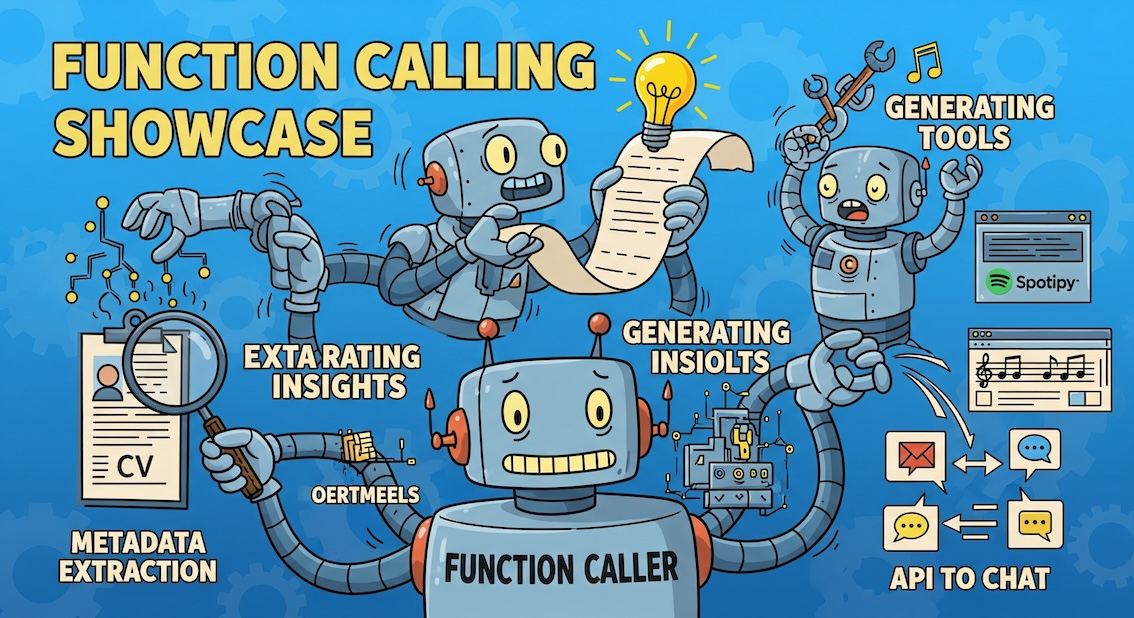

# Introduction

This notebook explores the capabilities of using OpenAI with function calling for various tasks. We will cover topics such as:

- Understanding and responding to user follow-up inquiries in a conversational context.
- Generating and utilizing tools to interact with external systems or databases.
- Extracting structured metadata and information from unstructured text, such as resumes.
- Generating insights and follow-up questions from large documents, like research papers.
- Working with multiple tool calls in parallel for complex tasks.
- Transforming existing APIs into conversational chat interfaces, demonstrated with the Spotipy API.

Through practical examples, we will demonstrate how function calling enables more dynamic and interactive applications with large language models.

# Summary

This notebook showcases various examples of utilizing OpenAI with function calling:

- Understand user follow-up inquiries
- To generate Tools
- Metadata Extraction (Information Extraction, check text-axis)
- Generating Insights and Follow-up Questions (Large document)
- Working with multiple tool calls in parallel (new version)
- Transform any API to chat-dialog: Spotipy

In [ ]:
!pip install -q openai pypdf langchain==0.1.1 langchain-community==0.0.13 langchain-openai==0.0.2.post1 spotipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.9/362.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.8/295.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.6/255.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0

In [ ]:
# from openai import AzureOpenAI, OpenAI

# client = AzureOpenAI(
#     api_key=userdata.get('AZURE_API_KEY'),
#     api_version=userdata.get('AZURE_API_VERSION'),
#     azure_endpoint=userdata.get('AZURE_BASE_URL')
# )

messages = [{'role': 'system', 'content': 'You are Mario from Nintendo'}]

user_message="Say hi for my audience"
messages.append({"role": "user", "content": user_message})
response = client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    # temperature=0.0,
    # seed=12345,
)
response

ChatCompletion(id='chatcmpl-A1bbc7XcGGVnH1PR4zwzUfbmwvxIS', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="It's-a me, Mario! Hello everyone! Let's-a go!", refusal=None, role='assistant', function_call=None, tool_calls=None), content_filter_results={'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}})], created=1724946248, model='gpt-4o-2024-05-13', object='chat.completion', service_tier=None, system_fingerprint='fp_80a1bad4c7', usage=CompletionUsage(completion_tokens=13, prompt_tokens=21, total_tokens=34), prompt_filter_results=[{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}])

In [ ]:
from google.colab import userdata
import os
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

## Understand user follow-up inquiries

In [ ]:
tools = [
    # tool
    {
            "type":"function",
            "function": {
                "name": "analyze_chat",
                "description": "Determine the user's intention by generating a question and ascertain whether it can be answered using the internet.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "user_intention": {
                            "type": "string",
                            "description": "A fully articulated user intention in question format regarding the chat log."
                        },
                        "is_personal_information": {
                            "type": "integer",
                            "description": "Determine whether the user requires private data, like hobbies, activities, and so on. Defaults to 0."
                        },
                        "can_be_answered_with_internet": {
                            "type": "boolean",
                            "description": "Determine whether it can be answered using the internet, considering information available up to 2 weeks prior, recently information can not be answered. Defaults to false."
                        },
                    },
                    "required": ["user_intention"]
                },
            }
    }
]

In [ ]:
from openai import AzureOpenAI, OpenAI

client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))
# client = AzureOpenAI(
#     api_key=userdata.get('AZURE_API_KEY'),
#     api_version=userdata.get('AZURE_API_VERSION'),
#     azure_endpoint=userdata.get('AZURE_BASE_URL')
# )
messages = [{'role': 'system', 'content': 'You are a useful assistant'}]

user_message="The CEO of Twitter and about their organization."
messages.append({"role": "user", "content": user_message})
completion= client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools
)

In [ ]:
completion.choices[0].message

ChatCompletionMessage(content=None, role='assistant', function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_f6oiMEtCYfVkPWlBJaj3arOt', function=Function(arguments='{"user_intention":"Information about the current CEO of Twitter and their organization.","is_personal_information":0,"can_be_answered_with_internet":true}', name='analyze_chat'), type='function')])

In [ ]:
completion.choices[0].message.tool_calls[0].function

Function(arguments='{"user_intention":"Information about the current CEO of Twitter and their organization.","is_personal_information":0,"can_be_answered_with_internet":true}', name='analyze_chat')

In [ ]:
messages = [{'role': 'system', 'content': 'You are a useful assistant'},
            {'role':"user", 'content': 'The CEO of Twitter and about their organization' },
            {'role':'assistant', 'content': 'Elon Musk completed his acquisition of Twitter in October 2022; \
            Musk acted as CEO of Twitter until June 2023 when he was succeeded by Linda Yaccarino. \
            Twitter was then rebranded to X in July 2023.'}]

followup_question="and meta" # user input
messages.append({"role": "user", "content": followup_question})
completion= client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools,
    tool_choice= 'auto'
)

In [ ]:
completion.choices[0].message.tool_calls[0].function

Function(arguments='{"user_intention": "Who is the CEO of Meta and information about their organization.", "is_personal_information": 0, "can_be_answered_with_internet": true}', name='analyze_chat')

In [ ]:
messages = [{'role': 'system', 'content': 'You are a useful assistant'},
            {'role':"user", 'content': 'Who is the CEO of Twitter and tell me about their organization?' },
            {'role':'assistant', 'content': 'Elon Musk completed his acquisition of Twitter in October 2022; \
            Musk acted as CEO of Twitter until June 2023 when he was succeeded by Linda Yaccarino. \
            Twitter was then rebranded to X in July 2023.'},
            {'role':"user", 'content': 'Who is the CEO of Meta and tell me about their organization?' },
            {'role':'assistant', 'content': 'As of my last update in early 2023, the CEO of Meta Platforms, Inc. \
             (formerly known as Facebook, Inc.) is Mark Zuckerberg. He co-founded Facebook in 2004 while he was a student at Harvard University  \
             and has led the company since its inception.'}]

messages.append({"role": "user", "content": "and the hobbies and activities from ceo of IBM "})
completion= client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools,
    tool_choice={"type": "function", "function": {"name": "analyze_chat"} }

)

In [ ]:
completion.choices[0].message.tool_calls[0].function

Function(arguments='{"user_intention":"What are the hobbies and activities of the CEO of IBM?","is_personal_information":1,"can_be_answered_with_internet":true}', name='analyze_chat')

## Dealing with Multiple Tools

In [ ]:
tools = [
    {
            "type":"function",
            "function": {
                "name": "analyze_chat",
                "description": "Determine the user's intention by generating a question and ascertain whether it can be answered using the internet.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "user_intention": {
                            "type": "string",
                            "description": "A fully articulated user intention in question format regarding the chat log."
                        },
                        "is_personal_information": {
                            "type": "integer",
                            "description": "Determine whether the user requires private data, like hobbies, activities, and so on. Defaults to 0."
                        },
                        "can_be_answered_with_internet": {
                            "type": "boolean",
                            "description": "Determine whether it can be answered using the internet, considering information available up to 2 weeks prior, recently information can not be answered. Defaults to false."
                        },
                    },
                    "required": ["user_intention"]
                },
            }
    },
    {
        "type": "function",
        "function": {
            "name": "search_nosql_database",
            "description": "Search for data within a NoSQL database using a flexible query structure.",
            "parameters": {
                "type": "object",
                "properties": {
                    "nosql_query": {
                        "type": "string",
                        "description": "A full script query specifying the search criteria for the NoSQL database."
                    },
                    "database_name": {
                        "type": "string",
                        "description": "The name of the NoSQL database to be searched."
                    },
                    "collection_name": {
                        "type": "string",
                        "description": "The specific collection within the NoSQL database to search."
                    },
                    "limit": {
                        "type": "integer",
                        "description": "The maximum number of results to return. Defaults to 10."
                    }
                },
                "required": ["nosql_query", "database_name", "collection_name"]
            },
        }
    },
    {
        "type": "function",
        "function": {
            "name": "search_sql_database",
            "description": "Execute a structured query language (SQL) search on a relational database.",
            "parameters": {
                "type": "object",
                "properties": {
                    "sql_query": {
                        "type": "string",
                        "description": "The full SQL query string to be executed on the relational database."
                    },
                    "database_name": {
                        "type": "string",
                        "description": "The name of the relational database to be queried."
                    },
                    # "constrains" ...
                },
                "required": ["sql_query", "database_name"]
            },
        }
    }
]

In [ ]:
system_prompt = """You are a useful assistant who interprets the user intent into a programming language for the following datasets:

- **Resumes/CVs Database Schema (MongoDB)**
  - Collection: `marketing_resumes`
    - `resume_id` (ObjectId): A unique identifier for each resume/CV.
    - `applicant_name` (String): The full name of the applicant.
    - `contact_information` (Object): An object containing the applicant's contact details such as email (String) and phone number (String).
    - `area_of_expertise` (String): The field or area the applicant specializes in, e.g., marketing.
    - `skills` (Array): A list of skills (String) and competencies the applicant possesses.
    - `work_experience` (Array): An array of objects detailing the applicant's work history.
    - `education` (Array): An array of objects outlining the applicant's educational background.
    - `submission_date` (Date): The date when the resume/CV was submitted to the database.

  - Collection: `other_areas_resumes`
    - `resume_id` (ObjectId): A unique identifier for each resume/CV.
    - `applicant_name` (String): The full name of the applicant.
    - `contact_information` (Object): An object containing the applicant's contact details such as email (String) and phone number (String).
    - `area_of_expertise` (String): The field or area the applicant specializes in, other than marketing.
    - `skills` (Array): A list of skills (String) and competencies the applicant possesses.
    - `work_experience` (Array): An array of objects detailing the applicant's work history.
    - `education` (Array): An array of objects outlining the applicant's educational background.
    - `submission_date` (Date): The date when the resume/CV was submitted to the database.

- **Banking Company Database Schema (MySQL)**
  - Table: `transactions`
    - `transaction_id` (INT, PRIMARY KEY, AUTO_INCREMENT): A unique identifier for each banking transaction.
    - `account_number` (VARCHAR): The account number associated with the transaction.
    - `account_holder` (VARCHAR): The name of the account holder.
    - `transaction_type` (ENUM): The type of transaction, such as deposit, withdrawal, payment, etc.
    - `amount` (DECIMAL): The monetary amount involved in the transaction.
    - `currency` (VARCHAR): The currency in which the transaction was made.
    - `transaction_date` (DATETIME): The date when the transaction occurred.
    - `branch_code` (VARCHAR): The code of the bank branch where the transaction took place.
    - `employee_id` (INT): An identifier for the employee who processed the transaction.

  - Table: `accounts`
    - `account_number` (VARCHAR, PRIMARY KEY): The unique account number for the bank account.
    - `account_holder` (VARCHAR): The name of the account holder.
    - `account_type` (ENUM): The type of account, such as checking, savings, etc.
    - `balance` (DECIMAL): The current balance of the account.
    - `currency` (VARCHAR): The currency of the account balance.
    - `creation_date` (DATETIME): The date when the account was created.
    - `branch_code` (VARCHAR): The code of the bank branch where the account was opened.
"""

In [ ]:
messages = [
    {'role': 'system',   'content': system_prompt},
    {'role': "user", 'content':
     'Can you provide a list of 15 applicants with expertise in data science who have submitted their resumes in the last month?, use tools or functions as possible'}
]

completion= client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools
)

In [ ]:
completion.choices[0].message.tool_calls[0].function

Function(arguments='{\n  "nosql_query": "{ \\"area_of_expertise\\": \\"data science\\", \\"submission_date\\": { \\"$gte\\": ISODate(new Date().setMonth(new Date().getMonth()-1)) } }",\n  "database_name": "resumes_db",\n  "collection_name": "other_areas_resumes",\n  "limit": 15\n}', name='search_nosql_database')

In [ ]:
import json
json.loads(completion.choices[0].message.tool_calls[0].function.arguments)

{'nosql_query': '{ "area_of_expertise": "data science", "submission_date": { "$gte": ISODate(new Date().setMonth(new Date().getMonth()-1)) } }',
 'database_name': 'resumes_db',
 'collection_name': 'other_areas_resumes',
 'limit': 15}

In [ ]:
messages = [
    {'role': 'system',   'content': system_prompt},
    {'role': "user", 'content': 'What is the total sum of deposits made at the branch with code "BR001" in the first quarter of this year?'}
]

completion= client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools
)

In [ ]:
completion

ChatCompletion(id='chatcmpl-9rp8eYGtEvsBnfbPn3UO3DYKnbCn9', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, role='assistant', function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_rrSACLt8v0A4l6uVA2XzqcQ1', function=Function(arguments='{"sql_query":"SELECT SUM(amount) as total_deposits FROM transactions WHERE branch_code = \'BR001\' AND transaction_type = \'deposit\' AND transaction_date BETWEEN \'2023-01-01\' AND \'2023-03-31\'","database_name":"banking_company"}', name='search_sql_database'), type='function')]), content_filter_results={})], created=1722614988, model='gpt-4o-2024-05-13', object='chat.completion', service_tier=None, system_fingerprint='fp_abc28019ad', usage=CompletionUsage(completion_tokens=69, prompt_tokens=1047, total_tokens=1116), prompt_filter_results=[{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'sever

In [ ]:
json.loads(completion.choices[0].message.tool_calls[0].function.arguments)

{'sql_query': "SELECT SUM(amount) as total_deposits FROM transactions WHERE branch_code = 'BR001' AND transaction_type = 'deposit' AND transaction_date BETWEEN '2023-01-01' AND '2023-03-31'",
 'database_name': 'banking_company'}

## Metadata Extraction (Information Extraction, check text-axis)

In [ ]:
from pydantic import BaseModel, Field
from langchain_community.chat_models import ChatOpenAI
from typing import List
from langchain.utils.openai_functions import convert_pydantic_to_openai_function

class Education(BaseModel):
    """
    Represents the educational qualifications of an individual.
    """
    course: str = Field(..., description="The course is the name of the course completed.")
    institute_or_university: str = Field(..., description="The institute_or_university is the name of the university or institute affiliated with the course.")
    date: str = Field(..., description="The date when the course was completed.")


class WorkExperience(BaseModel):
    """
    Call with the information of projects completed or infer gaps in the individual
    """
    company_name: str = Field(..., description="The company_name is the name of the company for example: 'MedSite', in the case of gaps, the name is 'gap'.")
    project_name: str = Field(..., description="The project_name is the name of the project for example: 'Matthews Interface & Internet Sales', if not exist should be empty.")
    experience_description: str = Field(..., description="A work experience description, must have 20 words as maximum.")
    time_frame: str = Field(..., description="The time frame should be in the format 'start_date - end_date' (YYYY/MM), for example, '2019/01 - 2020/02'")
    duration_months: int = Field(..., description="Calculate the duration_months as an integer representing the number of months from the project time frame.")

class Resume(BaseModel):
    """
    Call this with information of a resume, today is 2024 March, so use for future denoting the time frame instead of until now or present.
    """
    name: str = Field(..., description="The full name must be applied capitalization correcttly")
    email: str = Field(..., description="The email of the individual from the resume or empty value")
    soft_skills: List[str] = Field(..., description="Infer the soft skills of an individual like communication, team work, list all the soft skills, extract skill by skill",
                                    min_items=5,
                                    max_items=10)
    hard_skills: List[str] = Field(..., description="Infer the hard skills like data analysis, machine learning , python programming, list all the skills, extract skill by skill",
                                    min_items=5,
                                    max_items=10)
    certifications: List[str] = Field(..., description="A list of official credentials earned by the individual to verify their legitimacy and competences. It is not related with the work experience. If not mentioned should be empty")
    references: List[str] = Field(..., description="A list of people or companies who can provide information about the individual.")
    education: List[Education] = Field(..., description="A list of educational qualifications")
    work_experience_or_gap: List[WorkExperience] = Field(..., description="The work_experience_or_gap is a list of different projects and professional work completed or gaps among them")
    aditional_info: str = Field(..., description="""A text with any additional information(activities, hobbies, sports, strengths, responsabilities, etc.),
                            and are not related to: any work experience, any education, any certifications, any references, any skills, nor programming languages,
                            and not use the additional information of the section if its mentioned explicity in the resume, because that section could be empty,
                            and must be written in passive voice""")
    summary: str = Field(..., description="""A summarized text with the whole information of the candidate expressing in a paragraph and a bullet point list. """)

chat = ChatOpenAI(model_name="gpt-4o", temperature=0.0)
enrolled_bill_function = convert_pydantic_to_openai_function(Resume)
chat_with_forced_function = chat.bind(functions=[enrolled_bill_function], function_call={"name":Resume.__name__})


In [ ]:
from langchain.prompts import ChatPromptTemplate, HumanMessagePromptTemplate, SystemMessagePromptTemplate
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
assistant_message="Think carefully, and then extract the metadata as instructed"
system_message_prompt = SystemMessagePromptTemplate.from_template(assistant_message)
human_message_prompt = HumanMessagePromptTemplate.from_template("{context}")
chat_prompt = ChatPromptTemplate.from_messages([system_message_prompt, human_message_prompt])
cv_chain =  chat_prompt | chat_with_forced_function | JsonOutputFunctionsParser()
type(cv_chain)

langchain_core.runnables.base.RunnableSequence

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
file_name = "/content/Function Calling - Learning by Doing - Resume.pdf"
loader = PyPDFLoader(file_name)
resume_content = loader.load()[0].page_content # raw

In [ ]:
resume_metadata = cv_chain.invoke({'context': resume_content})

In [ ]:
from pprint import pprint
pprint(resume_metadata, width=150)

{'aditional_info': 'Empowering people and building team rapport is enjoyed by the candidate. Effective and efficient manager who maximizes available '
                   'resources and utilizes the latest technology to stay ahead of the competition. Strongly committed to quality processes.',
 'certifications': ['McCormick Solutions Inc., Houston, TX - 04/2003 – Present'],
 'education': [],
 'email': '',
 'hard_skills': ['Perimeter Security',
                 'Biometrics Technology',
                 'Electronic Document Management',
                 'Intrusion Detection',
                 'Wireless Networking',
                 'VPN Services'],
 'name': 'Kent Abercrombie',
 'references': [],
 'soft_skills': ['Effective communication', 'Teamwork', 'Analytical skills', 'Organizational skills', 'Leadership'],
 'summary': 'Kent Abercrombie is a high-tech professional with over twenty-four years of experience in Information Technology. He is a skillful '
            'coordinator with solid 

## Generating Insights and Follow-up (Large document)

In [ ]:
# The 'YOLO-World: Real-Time Open-Vocabulary Object Detection' paper
loader = PyPDFLoader("https://arxiv.org/pdf/2401.17270.pdf")
resume_content = loader.load()[0].page_content

In [ ]:
from pydantic import BaseModel, Field
from typing import List

class Paper(BaseModel):
    """
    A model representing a research paper, designed to facilitate the extraction and analysis of valuable insights to promote further growth and research.
    """
    insights: List[str] = Field(
        ...,
        description="A curated list of key insights derived from the paper that are deemed valuable for understanding and extending the work.",
        min_items=5,
        max_items=10,
    )
    followup_questions: List[str] = Field(
        ...,
        description="A collection of thought-provoking questions that arise from the paper's content, intended to guide future research and exploration.",
        min_items=5,
        max_items=10,
    )

In [ ]:
chat_with_forced_function = chat.bind(functions=[convert_pydantic_to_openai_function(Paper)], function_call={"name":Paper.__name__})
cv_chain =  chat_prompt | chat_with_forced_function | JsonOutputFunctionsParser()
paper_information = cv_chain.invoke({'context': resume_content})

In [ ]:
pprint(paper_information, width=150)

{'followup_questions': ['How can the RepVL-PAN network and region-text contrastive loss be further optimized for even better performance in '
                        'open-vocabulary object detection?',
                        "What are the potential applications of YOLO-World's open-vocabulary detection capabilities beyond object detection and "
                        'instance segmentation?',
                        "How does YOLO-World's performance compare to other state-of-the-art methods in terms of computational efficiency and "
                        'deployment on edge devices?',
                        'What are the key challenges in scaling up YOLO-World for even larger datasets and more diverse object categories?',
                        'How can the vision-language modeling approach of YOLO-World be adapted for other computer vision tasks beyond object '
                        'detection?'],
 'insights': ['YOLO-World introduces an innovative approach to enhance YOLO wi

## Working with multiple tool calls in parallel (new version)

### LLM Compiler: https://arxiv.org/abs/2312.04511
<p align="center">
  <img src="https://raw.githubusercontent.com/langchain-ai/langgraph/4569be0e02f4920bf4979a3c9565cfc442f0f300/examples/llm-compiler/img/llm-compiler.png" width="600">
</p>

### Plan and Solve: https://arxiv.org/abs/2305.04091

<p align="center">
  <img src="https://raw.githubusercontent.com/langchain-ai/langgraph/4569be0e02f4920bf4979a3c9565cfc442f0f300/examples/plan-and-execute/img/plan-and-execute.png" width="600">
</p>


### Reasoning without Observation: https://arxiv.org/abs/2305.18323

<p align="center">
  <a href="https://colab.research.google.com/github/langchain-ai/langgraph/blob/main/examples/rewoo/rewoo.ipynb">
    <img src="https://raw.githubusercontent.com/langchain-ai/langgraph/4569be0e02f4920bf4979a3c9565cfc442f0f300/examples/rewoo/img/rewoo.png" width="600">
  </a>
</p>

## Transform any API to chat-dialog: Spotipy

In [ ]:
os.environ['SPOTIPY_CLIENT_ID'] = userdata.get('SPOTIPY_CLIENT_ID')
os.environ['SPOTIPY_CLIENT_SECRET'] = userdata.get('SPOTIPY_CLIENT_SECRET')

In [ ]:
import spotipy
import os
import openai
from spotipy.oauth2 import SpotifyClientCredentials
# Set up your Spotify API credentials
client_credentials_manager = SpotifyClientCredentials()
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

In [ ]:
import json
from pprint import pprint

def list_latest_episode_of_spotify_show(show_name: str, limit: int=40) -> str:
    """Get the latest episodes of a determine show or episode in a given name"""
    result_fetch = sp.search(show_name, limit=limit, offset=10, type='episode',market='ES')
    final_list = []
    for item in result_fetch['episodes']['items']:
            final_list.append({'release_date':item['release_date'],
                               'episode_name':item['name'],
                               'url':item['external_urls']['spotify']})
    # sort the list by the release date
    final_list = sorted(final_list, key=lambda x: x['release_date'], reverse=True)
    return final_list

In [ ]:
result_fetch = list_latest_episode_of_spotify_show('Globant',3)
pprint(result_fetch)

[{'episode_name': 'Eps.20 | New Technology: Part 1 - Leveraging AI to Unlock '
                  'Creative Potential in Media',
  'release_date': '2024-01-10',
  'url': 'https://open.spotify.com/episode/3gPzHF8oIq9Hiuy4cVTk8x'},
 {'episode_name': 'Apertura: ¿Qué pasó con Globant? | #Segurola',
  'release_date': '2023-12-26',
  'url': 'https://open.spotify.com/episode/6pCoduFRF3twt4za9FQcxk'},
 {'episode_name': 'Selveste Sydney med lytterfavoritt Thor Gotaas',
  'release_date': '2023-11-13',
  'url': 'https://open.spotify.com/episode/5zIW7s3jhSxHaEuODULiVa'}]


In [ ]:
tools = [
    {
        "type":"function",
        "function": {
            "name": "list_latest_episode_of_spotify_show",
            "description": "Get the latest episodes  from Spotify shows or episodes in a given name",
            "parameters": {
                "type": "object",
                "properties": {
                    "show_name": {
                        "type": "string",
                        "description": "The name of the show or episode, e.g., Apple, Globant, Twitter, Amazon",
                    },
                    "limit": {
                        "type": "integer",
                        "description": "The maximum number of items to fetch, i.e. 5", # "five"
                    },

                },
                "required": ["show_name"],
            },
        }
    }
]

In [ ]:
%%writefile spotify_utils.py
import json
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

client_credentials_manager = SpotifyClientCredentials()
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

def list_latest_episode_of_spotify_show(show_name, limit=20):
    """Get the latest episodes of a determine show or episode in a given name"""
    result_fetch = sp.search(show_name, limit=40, offset=0, type='episode',market='ES')
    final_list = []
    for item in result_fetch['episodes']['items']:
            final_list.append({'release_date':item['release_date'],
                               'episode_name':item['name'],
                               'url':item['external_urls']['spotify']})
    return json.dumps(final_list[:limit])

Overwriting spotify_utils.py


In [ ]:
import spotify_utils
available_functions = {
    'list_latest_episode_of_spotify_show': spotify_utils.list_latest_episode_of_spotify_show,
    # another tool...
    'search_user_opinions_in_twitter': twitter_api.search_opinions,
    # another tool...
    'transcript_spotify_show': spotify_utils.transcript_spotify_show,
    # another tool...
    'extract_insights_spotify_show': spotify_utils.extract_insights_spotify_show,
}
client = openai.OpenAI()
def askToSpotifyBot(user_input, functions=tools):
    """
    Interacts with a Spotify bot to find podcasts and return a list with markdown links.

    Args:
        user_input (str): The user's input/query.
        functions (dict): A dictionary containing available functions for interaction.

    Returns:
        str: Formatted response containing podcast list or function output.
    """

    # Initial system message
    messages = [{'role': 'system', 'content': """
        You are an assistant helping me find podcasts on Spotify and returning the entire list.
        Please reply in markdown format and add the link(uri/url) at the end of each episode using [Listen here](url)""" }]

    # Add user input to messages
    messages.append({"role": "user", "content": user_input})

    # Call the GPT-3 model for initial completion
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        tools = tools,
        temperature=0.3,
    )

    response_message = response.choices[0].message
    tool_calls = response_message.tool_calls
    messages.append(response_message)
    if tool_calls:
        for tool_call in tool_calls:
            function_name = tool_call.function.name
            function_to_call = available_functions[function_name]
            function_args = json.loads(tool_call.function.arguments)
            function_response = function_to_call(**function_args)
            messages.append(
                {
                    "tool_call_id": tool_call.id,
                    "role": "tool",
                    "name": function_name,
                    "content": function_response,
                }
            )  # extend conversation with function response
        second_response = client.chat.completions.create(
            model="gpt-4o",
            messages=messages,
        )  # get a new response from the model where it can see the function response
        return second_response.choices[0].message.content
    else:
        return response_message.content


In [ ]:
from IPython.display import Markdown
Markdown(askToSpotifyBot("What are the latest 7 episodes of Twitter? Be concise"))

Here are the latest 7 episodes of the "Twitter" podcast:

1. [Kamal Fan Bashes Kamal! | Twitter Time Pass Space](https://open.spotify.com/episode/3uXtiCcVKnohRiljooJwD1)
2. [553: UFC 299: Vice City](https://open.spotify.com/episode/0MFgqw96Z6qtlT5GkNUPLJ)
3. [Revisiting WCW Nitro 1999 The Debut of Seven, WCW World Title Tournament, US Title Texas Tornado Ladder Match](https://open.spotify.com/episode/4u8JZMG71YkPVk2k3QIRrX)
4. [#1MonthOf TVK | Twitter Time Pass Space](https://open.spotify.com/episode/2NDDifyg5ROdxDnJxDBL38)
5. [Free Relationship Advise | Twitter Time Pass Space](https://open.spotify.com/episode/7Er4K7i2c5QcbV1YGEe9qZ)
6. [552: Biggest Stars In MMA? Ft. Laura Sanko](https://open.spotify.com/episode/3XnZitvOMjNEA6KM2wM6GG)
7. [551: "He's F***ing Fat" Francis Ngannou Meets Jon Jones Over The Weekend](https://open.spotify.com/episode/4tCRzrZsOFWSz2siACZjeu)

In [ ]:
Markdown(askToSpotifyBot("What are the latest 10 episodes of Globant? Group by year and month"))

### 2024
- February
    - [Eps.24 | Media & Entertainment: Pioneering innovation in Gaming: An interview with Globant's Paul Depre](https://open.spotify.com/episode/2I0vIhnEHZ7vl4VNmPD77T) [Listen here]
    - [De buenos Aires a Madrid: el codesarrollo en Globant Gaming](https://open.spotify.com/episode/3wJsD9FVWwtAKXdE9xMTJv) [Listen here]
    - [Martin Migoya, Founder and CEO at Globant: The $10B Startup Story](https://open.spotify.com/episode/5tEvIMEBy5YhtKVAhTWCez) [Listen here]
    - [NOP T5- EP45 Patricia Pomies: COO en Globant nos comparte su enfoque para un Crecimiento Sostenible y sus estrategias liderando la Brecha de Género en tecnología](https://open.spotify.com/episode/1KnNyRIfoUNKvL56xrlKDx) [Listen here]
- January
    - [Globant Takes A Design-First Approach to Pure Play Digital Service](https://open.spotify.com/episode/2UBGNXb7iqBp6iiRY8Ud3M) [Listen here]
    - [Anselmo Ramos Returns](https://open.spotify.com/episode/3NXvIY1czpUkw0L0jiZsSR) [Listen here]
    - [Inteligencia Artificial: Esteban Molina - Site Manager Globant - ¿Cómo utilizar la inteligencia artificial en los negocios para aumentar las capacidades humanas?](https://open.spotify.com/episode/21ijkaaME4x9JUpMAnmcsS) [Listen here]
- 2023
    - December
        - [Apertura: ¿Qué pasó con Globant? | #Segurola](https://open.spotify.com/episode/6pCoduFRF3twt4za9FQcxk) [Listen here]
    - September
        - [Eps.10 | New Technology: Gen Ai in Media & Entertainment, an interview with JJ Lopez Murphy, Head of AI at Globant](https://open.spotify.com/episode/2HVttgZueNScSBPvpFxsw5) [Listen here]

In [ ]:
Markdown(askToSpotifyBot("What are the latest 15 episodes of Bitcoin? Group by month and change 'Listen here' link to 'Escuchame'"))

### March 2024
- [BTC172: Macro Outlook Q1 2024 w/ Luke Gromen (Bitcoin Podcast)](https://open.spotify.com/episode/0FVq1TA85UBPEgBaUiwVUG) - Escuchame
- [Should've invested in bitcoin. 5th March 2024.](https://open.spotify.com/episode/49Gqna9tj22OZqXt1tqmLV) - Escuchame
- [The Bitcoin Strategy with Grant Gilliam - WBD782](https://open.spotify.com/episode/4SyvOhxiL4VxQ5AMHjWJvU) - Escuchame
- [The Year of Sound Money with Doomberg - WBD781](https://open.spotify.com/episode/5KaWIGG78eFbJ4scRplcBl) - Escuchame
- [ROLLUP: Bitcoin ATH's In Sight | Coinbase Crashes | Blast Mainnet Live](https://open.spotify.com/episode/1zuauzo4AiGo6D2D8n9DTr) - Escuchame

### February 2024
- [#05 Bitcoins dezentrales Nervensystem](https://open.spotify.com/episode/7nPpivmGt9TCgJzRCLEluB) - Escuchame
- [Scaling Bitcoin Privately with John Light - WBD780](https://open.spotify.com/episode/4FwL9ReAhk1AjdbWvn6KsX) - Escuchame
- [Bitcoin is Eating the World with John Arnold - WBD779](https://open.spotify.com/episode/33DyswLqVFgWKYax5kkMMt) - Escuchame
- [The Right to Bitcoin with Dennis Porter - WBD778](https://open.spotify.com/episode/2sKDy29sFzdLCWL2EYxGMO) - Escuchame
- [Will the Dollar Implode? With Macro Alf - WBD777](https://open.spotify.com/episode/7xagd1zC1b4LMsTxEhZ6VQ) - Escuchame
- [The Bitcoin Scaling Dilemma with Shinobi - WBD776](https://open.spotify.com/episode/0RUODb31MZh3G3W7UqD4VG) - Escuchame
- [The Bitcoin Revolution with Quoth The Raven - WBD775](https://open.spotify.com/episode/2omJPkkw51QpJPtpmac7nT) - Escuchame

### February 2024
- [13. Korkoa korolle bitcoinista OSA 1: Haluatko työskennellä, kunnes kuol](https://open.spotify.com/episode/3lncjr4iq6HA9hzZmYvyhd) - Escuchame
- [CAN A TEAM BUILT ON BITCOIN REACH THE PREMIER LEAGUE? How To Run A Football Club Ep6 - Peter McCormack with Spencer Owen](https://open.spotify.com/episode/5xmJ9WP0URoOe7qN1jgZSF) - Escuchame
- [Why We Shouldn't Trust BlackRock with Whitney Webb & Mark Goodwin - WBD774](https://open.spotify.com/episode/0Li2dPFOS6ZaRXPiGgyps2) - Escuchame

In [ ]:
# First run
display(Markdown(askToSpotifyBot("What are the latest 3 episodes of metaverse? ")))
# Second run
Markdown(askToSpotifyBot("What are the latest 3 episodes of metaverse? Give me the full answer in spanish, include the titles"))

Here are the latest 3 episodes of "Metaverse":

1. **The Metaverse: How Mark Zuckerberg Lied To The World**  
   *Released on March 6, 2024*  
   [Listen here](https://open.spotify.com/episode/5UUXk3oBGj4tPCuglnHvM4)

2. **Addressing Web3 decentralization through AI with Ruth Galvin**  
   *Released on February 19, 2024*  
   [Listen here](https://open.spotify.com/episode/6w4wUChQS29jP1Y3IWEfIj)

3. **Bringing the Physical World On Chain, with Outlier Ventures**  
   *Released on February 5, 2024*  
   [Listen here](https://open.spotify.com/episode/5KNUBZ41tUUBwIbFEV8oxr)

Aquí están los últimos 3 episodios de Metaverse:

1. "El Metaverso: Cómo Mark Zuckerberg mintió al mundo" - Fecha de lanzamiento: 06 de marzo de 2024. [Escuchar aquí](https://open.spotify.com/episode/5UUXk3oBGj4tPCuglnHvM4)

2. "Abordar la descentralización de Web3 a través de la inteligencia artificial con Ruth Galvin" - Fecha de lanzamiento: 19 de febrero de 2024. [Escuchar aquí](https://open.spotify.com/episode/6w4wUChQS29jP1Y3IWEfIj)

3. "Llevando el mundo físico a la cadena, con Outlier Ventures" - Fecha de lanzamiento: 05 de febrero de 2024. [Escuchar aquí](https://open.spotify.com/episode/5KNUBZ41tUUBwIbFEV8oxr)

# Conclusion

This notebook has demonstrated the power and flexibility of integrating OpenAI's function calling capabilities into various workflows. We have seen how function calling allows the language model to interact with external tools and data sources, enabling it to perform tasks beyond simple text generation.

Key takeaways from this notebook include:

- **Enhanced Conversational AI:** Function calling allows models to understand context and user intent more deeply, leading to more natural and helpful conversations, especially with follow-up questions.
- **Structured Data Extraction:** We've shown how to use function calling to extract structured information from unstructured text, which is crucial for tasks like data processing and analysis.
- **Improved Document Understanding:** The ability to generate insights and questions from large documents highlights the potential of function calling in research, analysis, and information retrieval.
- **Orchestrating Complex Workflows:** The examples of working with multiple tools and transforming APIs into chat interfaces illustrate how function calling can be used to build more sophisticated and integrated applications.

By leveraging function calling, developers can build more intelligent, interactive, and capable applications that bridge the gap between language models and external services. This opens up a wide range of possibilities for creating innovative solutions in various domains.